# Stage 12: ML2, the image judge

**The same task as the feature judge — identical rows, identical labels —
but the model sees a 64×64 picture of the arrangement instead of six
numbers about it.**

Channel 0 carries the load-bearing wall centrelines, channel 1 the columns
as 3×3 blobs; the bounding box of everything drawn is fitted to the
canvas, so absolute units vanish. That is the design argument for an image
judge on this corpus: the mixed unit systems (metres, SVG pixels,
decimetre-ish) that force ML1 down to six scale-invariant features simply
disappear under rasterisation. The stated cost is the mirror image: once
everything is scaled to fit, no picture can know a span is 6 m rather
than 6 ft (loophole L8 — a deliberate trade).

Negatives are the shared geometry-space corruptions of stage 07,
**rasterised after corruption** — pixel-space noise would have reproduced
in pictures exactly the circularity the feature judge just had removed.

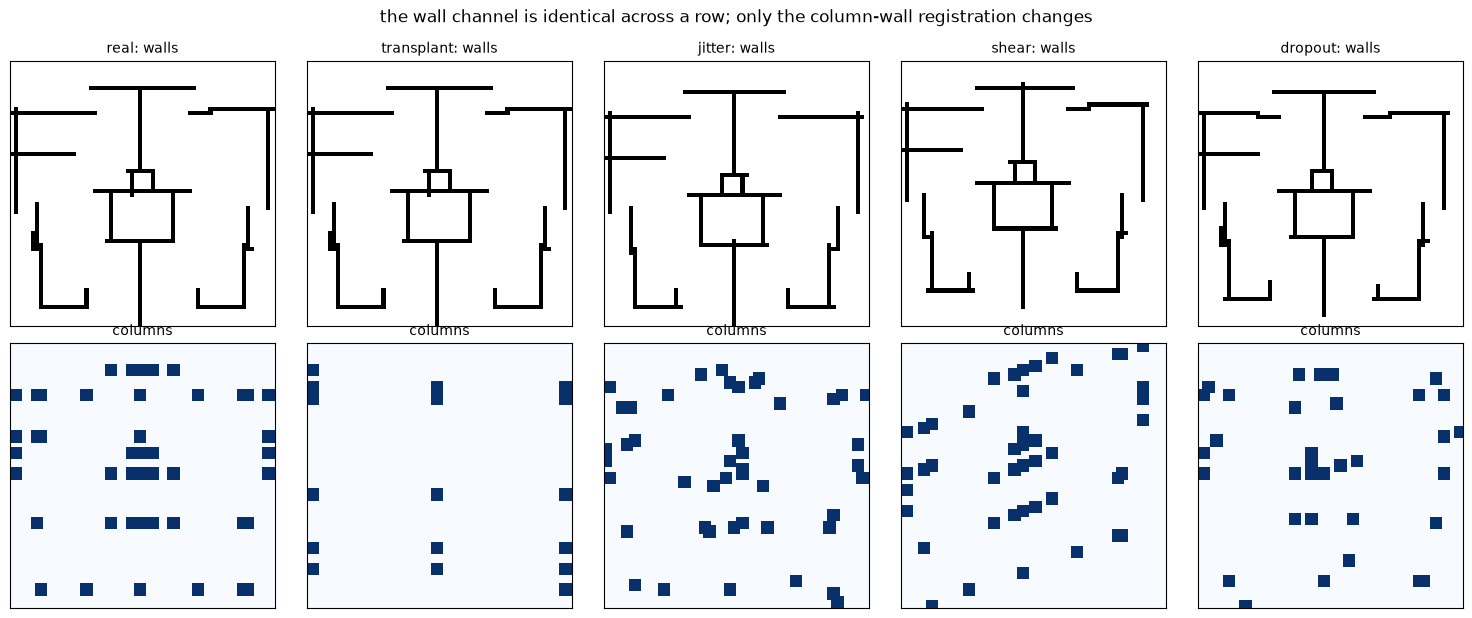

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "09_full_pipeline"))
import pipeline as P

# what the network actually sees: one plan, real and corrupted
corpus = P.load_judge_corpus()
walls = pd.read_csv(Path("..") / "data" / "lb_walls.csv.gz")
wall_map = {(s, str(i)): w for s, i, w in
            zip(walls.source, walls.id, walls.walls)}
rng = np.random.default_rng(7)
row = corpus.iloc[100]
w5 = np.array([[float(v) for v in seg.split()]
               for seg in wall_map[(row.source, str(row.id))].split(";")])
donor = corpus.points.iloc[2000]
sets = [("real", row.points)] + [
    (k, P.corrupt_columns(row.points, k, rng, donor=donor))
    for k in P.NEGATIVE_KINDS]
fig, axes = plt.subplots(2, 5, figsize=(15, 6.2))
for j, (name, pts) in enumerate(sets):
    img = P.rasterise(pts, w5)
    axes[0, j].imshow(img[..., 0], cmap="Greys", origin="lower")
    axes[0, j].set_title(f"{name}: walls", fontsize=10)
    axes[1, j].imshow(img[..., 1], cmap="Blues", origin="lower")
    axes[1, j].set_title("columns", fontsize=10)
    for ax in (axes[0, j], axes[1, j]):
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("the wall channel is identical across a row; only the "
             "column-wall registration changes", y=0.99)
fig.tight_layout()
fig.savefig(Path("..") / "figures" / "11_inputs.png", dpi=150,
            bbox_inches="tight")
plt.show()

## The three-way result

The training scripts (`train_ml2.py`, `train_ml2_ablation.py`) fit the
CNN (three conv blocks, global pooling, ~15k weights) on grouped splits
over three seeds, with a **paired** feature control — boosting fitted on
the features of exactly the same rows and scored on exactly the same
split indices — and then the decisive ablation: the same CNN with the
wall channel blanked.

In [2]:
res = pd.read_csv(Path("..") / "data" / "ml2_results.csv")
pooled = res[res.test == "pooled"]
print("pooled, grouped splits x3 (mean ± std):")
print(pooled.groupby("model")[["roc_auc", "pr_auc"]]
      .agg(["mean", "std"]).round(3).to_string())
print()
loso = res[res.train.isin(["Swiss", "CubiCasa"])]
print("leave-one-source-out:")
print(loso[["model", "train", "test", "roc_auc", "pr_auc"]]
      .round(3).to_string(index=False))

pooled, grouped splits x3 (mean ± std):
                                  roc_auc        pr_auc       
                                     mean    std   mean    std
model                                                         
ML1 boosting on features (paired)   0.860  0.007  0.830  0.010
ML2 CNN on pictures                 0.995  0.003  0.995  0.003
ML2 CNN, columns only               0.874  0.019  0.819  0.032

leave-one-source-out:
                            model    train     test  roc_auc  pr_auc
              ML2 CNN on pictures    Swiss CubiCasa    0.983   0.983
ML1 boosting on features (paired)    Swiss CubiCasa    0.673   0.608
              ML2 CNN on pictures CubiCasa    Swiss    0.988   0.989
ML1 boosting on features (paired) CubiCasa    Swiss    0.805   0.727
            ML2 CNN, columns only    Swiss CubiCasa    0.771   0.654
            ML2 CNN, columns only CubiCasa    Swiss    0.769   0.699


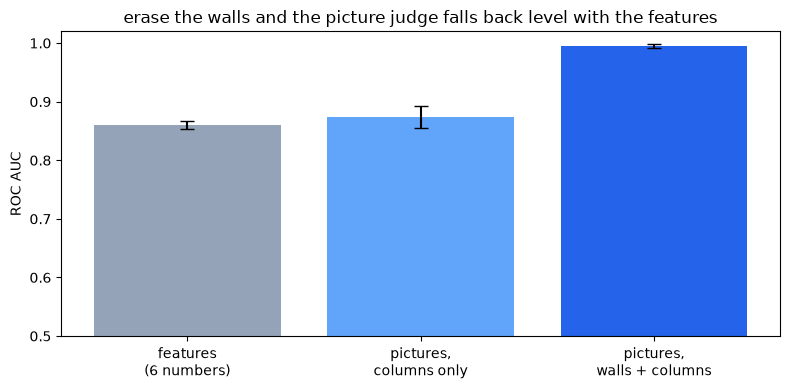

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
means = pooled.groupby("model").roc_auc.agg(["mean", "std"])
order = ["ML1 boosting on features (paired)", "ML2 CNN, columns only",
         "ML2 CNN on pictures"]
labels = ["features\n(6 numbers)", "pictures,\ncolumns only",
          "pictures,\nwalls + columns"]
colors = ["#94a3b8", "#60a5fa", "#2563eb"]
ax.bar(labels, [means.loc[m, "mean"] for m in order],
       yerr=[means.loc[m, "std"] for m in order],
       color=colors, capsize=5)
ax.set_ylim(0.5, 1.02); ax.set_ylabel("ROC AUC")
ax.set_title("erase the walls and the picture judge falls back level "
             "with the features")
fig.tight_layout()
fig.savefig(Path("..") / "figures" / "11_cnn_vs_features.png", dpi=150,
            bbox_inches="tight")
plt.show()

## What the ablation proves, and the caveat it carries

**Same information, same score.** With the wall channel blanked the CNN
lands at 0.874 ± 0.019 against the paired feature model's 0.860 ± 0.007 —
overlapping intervals. Convolution does not read column patterns better
than boosting reads descriptors of them.

**The plan context is the whole advantage.** With walls visible the CNN
reaches 0.995 ± 0.003 and stays at 0.983–0.988 on a source it never
trained on. Every negative kind — jitter, shear, dropout, transplant —
breaks column-wall registration, and the picture judge sees it directly.

**The caveat, stated wherever this signal appears:** the ground truth was
*derived* from load-bearing walls, so "real columns register with walls"
is partly the derivation read back. The same note attaches to
`t_off_wall` and to its dominant learned weight in stage 08. One
consistent finding, three appearances: on this corpus, the strongest
plausibility signal any judge can have is whether the columns live in
the walls — and only the representations that can see the walls get it.

**The superseded conclusion.** The earlier version of this stage found
"features win, clearly and repeatably" (0.841 vs 0.725). That was a
different task: grid-line images with a fabricated lattice of columns, on
the old ground truth, with no wall channel. On lines alone, features did
win; on arrangements with plan context, pictures do. Both results stay in
the record with their dates.